In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
sources = pd.read_csv('/home/yuan/JWST/CentralDogma/2_Lust_/merged_5sigv2.csv')
Sonora_model = pd.read_csv('ABmag_table.csv')
ATMO_model = pd.read_csv('ATMO_mag_table.csv')
LOWZ_model = pd.read_csv('LOWZ_mag_table.csv')

# ALL

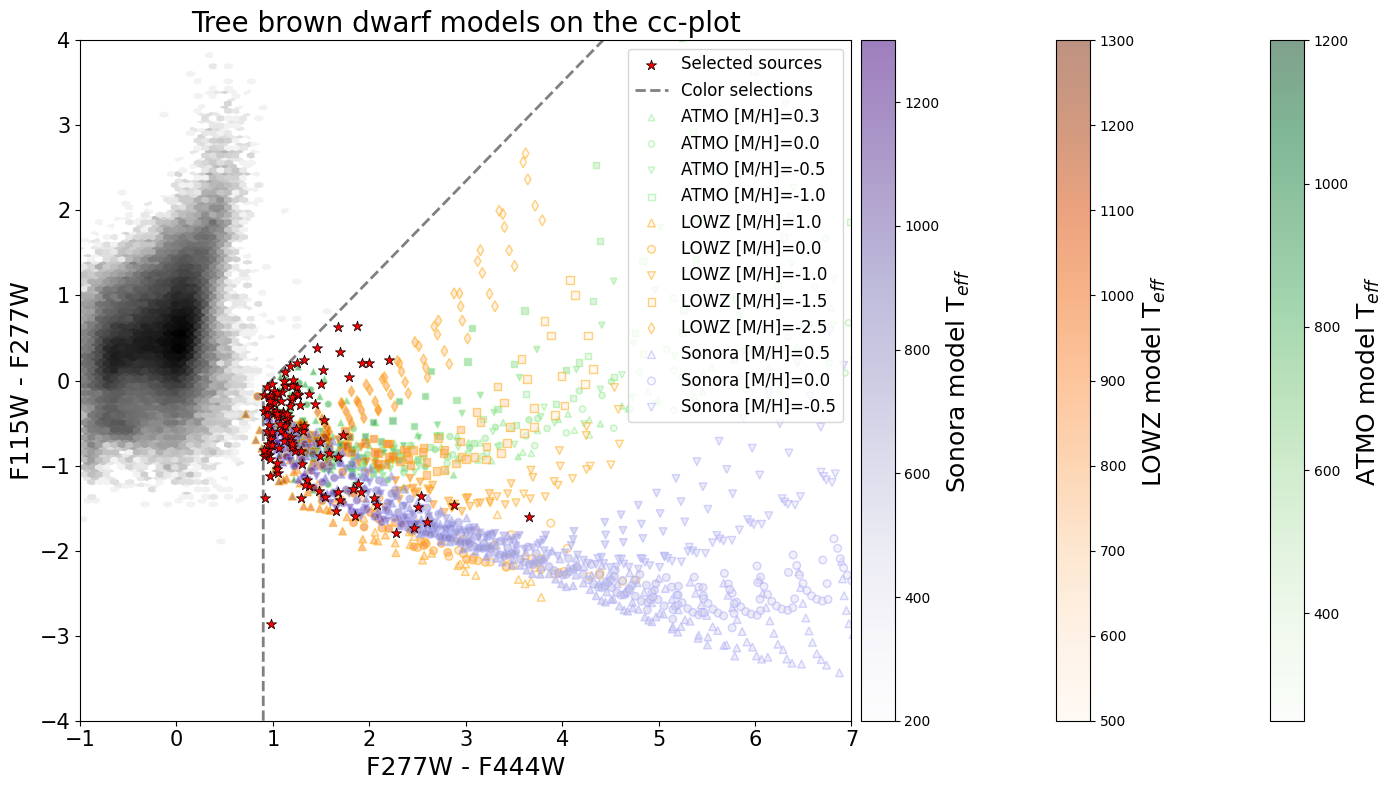

In [32]:
mask = (sources['MAG_AUTO_F444W']>10)&(sources['MAG_AUTO_F277W']>10)&(sources['MAG_AUTO_F150W']>10)&(sources['MAG_AUTO_F115W']>10)
m444 = sources[mask]['MAG_AUTO_F444W']
m277 = sources[mask]['MAG_AUTO_F277W']
m150 = sources[mask]['MAG_AUTO_F150W']
m115 = sources[mask]['MAG_AUTO_F115W']

selection = (m277-m444>0.9)&(m115-m277+1<m277-m444)
pltlim = [7, -4]

fig, ax = plt.subplots(figsize=(15,8))

hb = ax.hexbin(
    m277-m444, m115-m277,
    gridsize=160, cmap='Greys', bins='log'
)
ax.scatter(
    (m277-m444)[selection], (m115-m277)[selection],
    s=60, color='red', edgecolors='k', linewidth=0.5, marker='*', label='Selected sources',
    alpha=1, zorder=10
)

ax.plot([0.9, 0.9, 7], [pltlim[1], -0.1, pltlim[0]], c='grey', ls='--', lw=2, label='Color selections')

S_model = lambda z: Sonora_model[(Sonora_model['Z']==z)&(Sonora_model['Teff']<1310)]
A_model = lambda z: ATMO_model[(ATMO_model['[M/H]']==z)]
L_model = lambda z, CO, Kzz: LOWZ_model[(LOWZ_model['logZ']==z)&(LOWZ_model['CtoO']==CO)&(LOWZ_model['logKzz']==Kzz)&(LOWZ_model['Teff']<1310)]
# (Sonora_model['log(g)']==4.5)&
# (ATMO_model['log_g']==4.5)&
# (LOWZ_model['logg']==4.5)&

for z, marker in zip([0.3, 0.0, -0.5, -1.0], ['^', 'o', 'v', 's']):
    ac = ax.scatter(
        A_model(z)['F277W']-A_model(z)['F444W'], A_model(z)['F115W']-A_model(z)['F277W'],
        label=f'ATMO [M/H]={z}', c = A_model(z)['Teff'], cmap='Greens',
        s=20, marker=marker, edgecolors='#88EE88', alpha=0.5
    )
cbar2 = fig.colorbar(ac, ax=ax, pad = 0.03)
cbar2.set_label('ATMO model T$_{eff}$', fontsize=18)

CtoO = 0.55
Kzz = 2
for z, marker in zip([1.0, 0.0, -1.0, -1.5, -2.5], ['^', 'o', 'v', 's', 'd']):
    lc = ax.scatter(
        L_model(z, CtoO, Kzz)['F277W']-L_model(z, CtoO, Kzz)['F444W'],
        L_model(z, CtoO, Kzz)['F115W']-L_model(z, CtoO, Kzz)['F277W'],
        label=f'LOWZ [M/H]={z}', c = L_model(z, CtoO, Kzz)['Teff'], cmap='Oranges',
        s=30, marker=marker, edgecolors='orange', alpha=0.5
    )
cbar3 = fig.colorbar(lc, ax=ax, pad = 0.05)
cbar3.set_label('LOWZ model T$_{eff}$', fontsize=18)

for z, marker in zip([0.5, 0.0, -0.5], ['^', 'o', 'v']):
    sc = ax.scatter(
        S_model(z)['F277W']-S_model(z)['F444W'], S_model(z)['F115W']-S_model(z)['F277W'],
        label=f'Sonora [M/H]={z}', c = S_model(z)['Teff'], cmap='Purples',
        s=30, marker=marker, edgecolors='#AAAAFF', alpha=0.5
    )
cbar1 = fig.colorbar(sc, ax=ax, pad = 0.01)
cbar1.set_label('Sonora model T$_{eff}$', fontsize=18)

ax.set_xlabel('F277W - F444W', fontsize=18)
ax.set_ylabel('F115W - F277W', fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=15)

ax.set_xlim(-1, pltlim[0])
ax.set_ylim(pltlim[1], 4)

ax.legend(loc = 'upper right', fontsize=12)

# plt.title(f'Models on the cc-plot, {len(m444[selection])} sources pass the selection', fontsize=20)
# plt.title(f'Models on the cc-plot, LOWZ C/O={CtoO}, logKzz={Kzz}', fontsize=20)
plt.title('Tree brown dwarf models on the cc-plot', fontsize=20)
plt.tight_layout()
plt.show()

# LOWZ

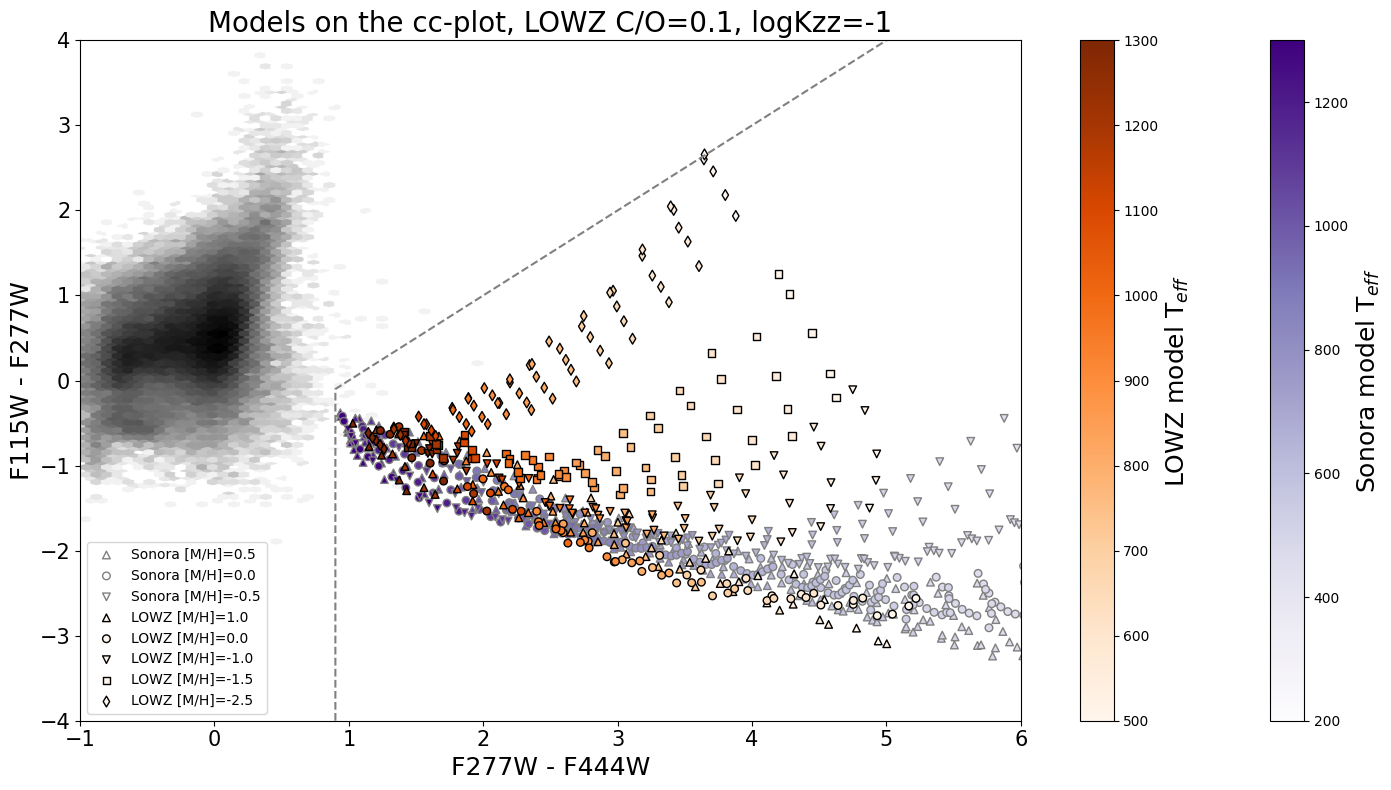

In [31]:
mask = (sources['MAG_AUTO_F444W']>10)&(sources['MAG_AUTO_F277W']>10)&(sources['MAG_AUTO_F150W']>10)&(sources['MAG_AUTO_F115W']>10)
m444 = sources[mask]['MAG_AUTO_F444W']
m277 = sources[mask]['MAG_AUTO_F277W']
m150 = sources[mask]['MAG_AUTO_F150W']
m115 = sources[mask]['MAG_AUTO_F115W']

# selection = (m277-m444>1.1)&(m115-m277<-0.8)
# selection = (m277-m444>1)
selection = (m277-m444>0.9)&(m115-m277+1<m277-m444)
pltlim = [6, -4]

fig, ax = plt.subplots(figsize=(15,8))

hb = ax.hexbin(
    m277-m444, m115-m277,
    gridsize=160, cmap='Greys', bins='log'
)
# ax.scatter(
#     (m277-m444)[selection], (m115-m277)[selection],
#     s=50, color='red', marker='*', label='Selected sources', alpha=0.5, zorder=10
# )
# ax.plot([1.1, 1.1, pltlim[0]], [pltlim[1], -0.8, -0.8], c='grey', ls='--')
# ax.plot([1, 1], [pltlim[1], pltlim[0]], c='grey', ls='--')
ax.plot([0.9, 0.9, 7], [pltlim[1], -0.1, pltlim[0]], c='grey', ls='--')

S_model = lambda z: Sonora_model[(Sonora_model['Z']==z)&(Sonora_model['Teff']<1310)]
A_model = lambda z: ATMO_model[(ATMO_model['[M/H]']==z)]
L_model = lambda z, CO, Kzz: LOWZ_model[(LOWZ_model['logZ']==z)&(LOWZ_model['CtoO']==CO)&(LOWZ_model['logKzz']==Kzz)&(LOWZ_model['Teff']<1310)]
# (ATMO_model['log_g']==5)&
# (Sonora_model['log(g)']==5)&


for z, marker in zip([0.5, 0.0, -0.5], ['^', 'o', 'v']):
    sc = ax.scatter(
        S_model(z)['F277W']-S_model(z)['F444W'], S_model(z)['F115W']-S_model(z)['F277W'],
        label=f'Sonora [M/H]={z}', c = S_model(z)['Teff'], cmap='Purples',
        s=30, marker=marker, edgecolors='grey'
    )
cbar1 = fig.colorbar(sc, ax=ax, pad = 0.01)
cbar1.set_label('Sonora model T$_{eff}$', fontsize=18)

# for z, marker in zip([-1.0, -0.5, 0.0, 0.3], ['s', 'v', 'o', '^']):
#     ac = ax.scatter(
#         A_model(z)['F277W']-A_model(z)['F444W'], A_model(z)['F115W']-A_model(z)['F277W'],
#         label=f'ATMO [M/H]={z}', c = A_model(z)['Teff'], cmap='Greens', s=20, marker=marker
#     )
# cbar2 = fig.colorbar(ac, ax=ax, pad = 0.03)
# cbar2.set_label('ATMO model T$_{eff}$', fontsize=18)

CtoO = 0.1
Kzz = -1
for z, marker in zip([1.0, 0.0, -1.0, -1.5, -2.5], ['^', 'o', 'v', 's', 'd']):
    lc = ax.scatter(
        L_model(z, CtoO, Kzz)['F277W']-L_model(z, CtoO, Kzz)['F444W'],
        L_model(z, CtoO, Kzz)['F115W']-L_model(z, CtoO, Kzz)['F277W'],
        label=f'LOWZ [M/H]={z}', c = L_model(z, CtoO, Kzz)['Teff'], cmap='Oranges',
        s=30, marker=marker, edgecolors='black'
    )
cbar3 = fig.colorbar(lc, ax=ax, pad = 0.05)
cbar3.set_label('LOWZ model T$_{eff}$', fontsize=18)

ax.set_xlabel('F277W - F444W', fontsize=18)
ax.set_ylabel('F115W - F277W', fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=15)

ax.set_xlim(-1, pltlim[0])
ax.set_ylim(pltlim[1], 4)

ax.legend(loc = 'lower left', fontsize=10)

# plt.title(f'Models on the cc-plot, {len(m444[selection])} sources pass the selection', fontsize=20)
plt.title(f'Models on the cc-plot, LOWZ C/O={CtoO}, logKzz={Kzz}', fontsize=20)
plt.tight_layout()
plt.show()

# ATMO

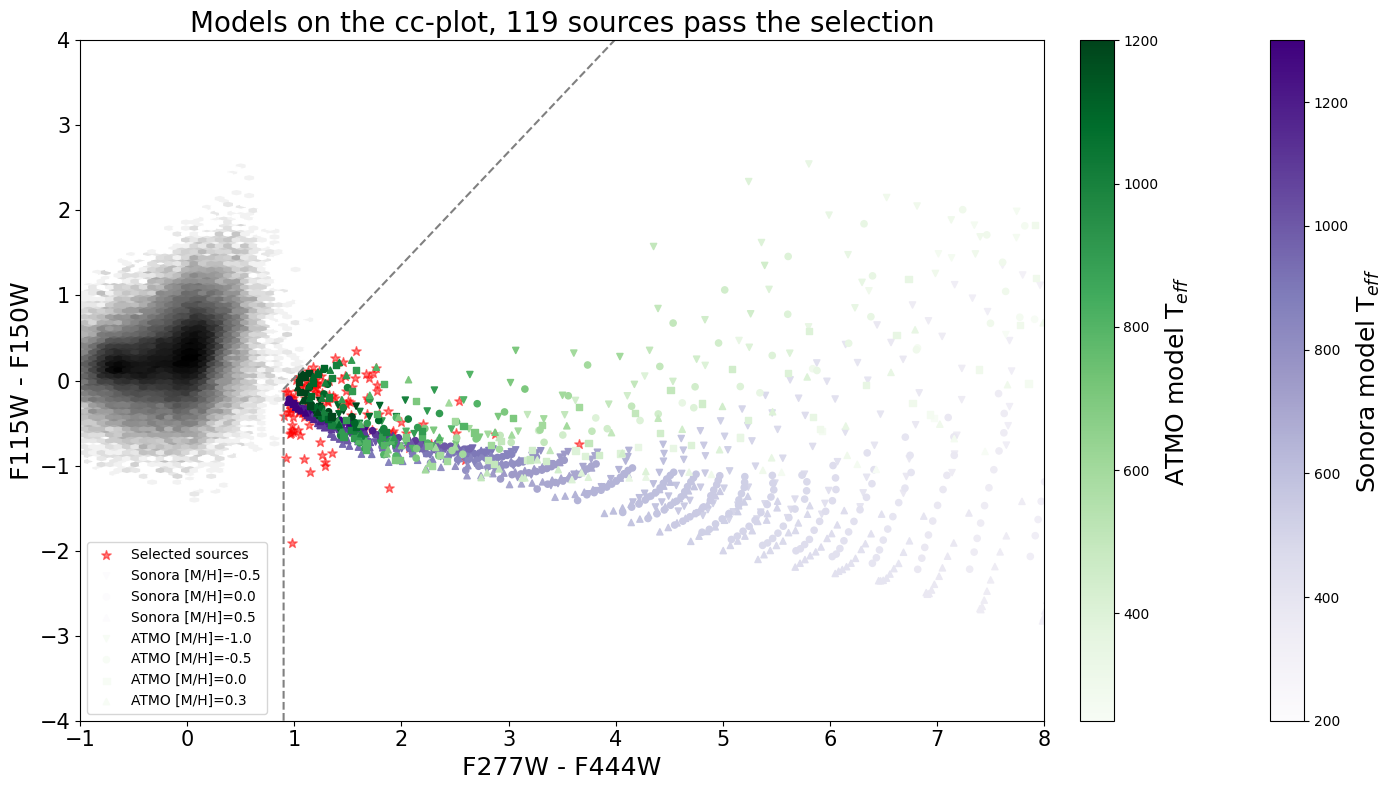

In [5]:
mask = (sources['MAG_AUTO_F444W']>10)&(sources['MAG_AUTO_F277W']>10)&(sources['MAG_AUTO_F150W']>10)&(sources['MAG_AUTO_F115W']>10)
m444 = sources[mask]['MAG_AUTO_F444W']
m277 = sources[mask]['MAG_AUTO_F277W']
m150 = sources[mask]['MAG_AUTO_F150W']
m115 = sources[mask]['MAG_AUTO_F115W']

# selection = (m277-m444>1.1)&(m115-m277<-0.8)
# selection = (m277-m444>1)
selection = (m277-m444>0.9)&(m115-m150+1<m277-m444)
pltlim = [8, -4]

fig, ax = plt.subplots(figsize=(15,8))

hb = ax.hexbin(
    m277-m444, m115-m150,
    gridsize=160, cmap='Greys', bins='log'
)
ax.scatter(
    (m277-m444)[selection], (m115-m150)[selection],
    s=50, color='red', marker='*', label='Selected sources', alpha=0.5
)
# ax.plot([1.1, 1.1, pltlim[0]], [pltlim[1], -0.8, -0.8], c='grey', ls='--')
# ax.plot([1, 1], [pltlim[1], pltlim[0]], c='grey', ls='--')
ax.plot([0.9, 0.9, 7], [pltlim[1], -0.1, pltlim[0]], c='grey', ls='--')

S_model = lambda z: Sonora_model[(Sonora_model['Z']==z)&(Sonora_model['Teff']<1310)]
A_model = lambda z: ATMO_model[(ATMO_model['[M/H]']==z)]
# (ATMO_model['log_g']==5)&
# (Sonora_model['log(g)']==5)&

for z, marker in zip([-0.5, 0.0, 0.5], ['v', 'o', '^']):
    sc = ax.scatter(
        S_model(z)['F277W']-S_model(z)['F444W'], S_model(z)['F115W']-S_model(z)['F150W'],
        label=f'Sonora [M/H]={z}', c = S_model(z)['Teff'], cmap='Purples', s=20, marker=marker
    )
cbar1 = fig.colorbar(sc, ax=ax, pad = 0.01)
cbar1.set_label('Sonora model T$_{eff}$', fontsize=18)

for z, marker in zip([-1.0, -0.5, 0.0, 0.3], ['v', 'o', 's', '^']):
    ac = ax.scatter(
        A_model(z)['F277W']-A_model(z)['F444W'], A_model(z)['F115W']-A_model(z)['F150W'],
        label=f'ATMO [M/H]={z}', c = A_model(z)['Teff'], cmap='Greens', s=20, marker=marker
    )
cbar2 = fig.colorbar(ac, ax=ax, pad = 0.03)
cbar2.set_label('ATMO model T$_{eff}$', fontsize=18)

ax.set_xlabel('F277W - F444W', fontsize=18)
ax.set_ylabel('F115W - F150W', fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=15)

ax.set_xlim(-1, pltlim[0])
ax.set_ylim(pltlim[1], 4)

ax.legend(loc = 'lower left', fontsize=10)

plt.title(f'Models on the cc-plot, {len(m444[selection])} sources pass the selection', fontsize=20)
plt.tight_layout()
plt.show()

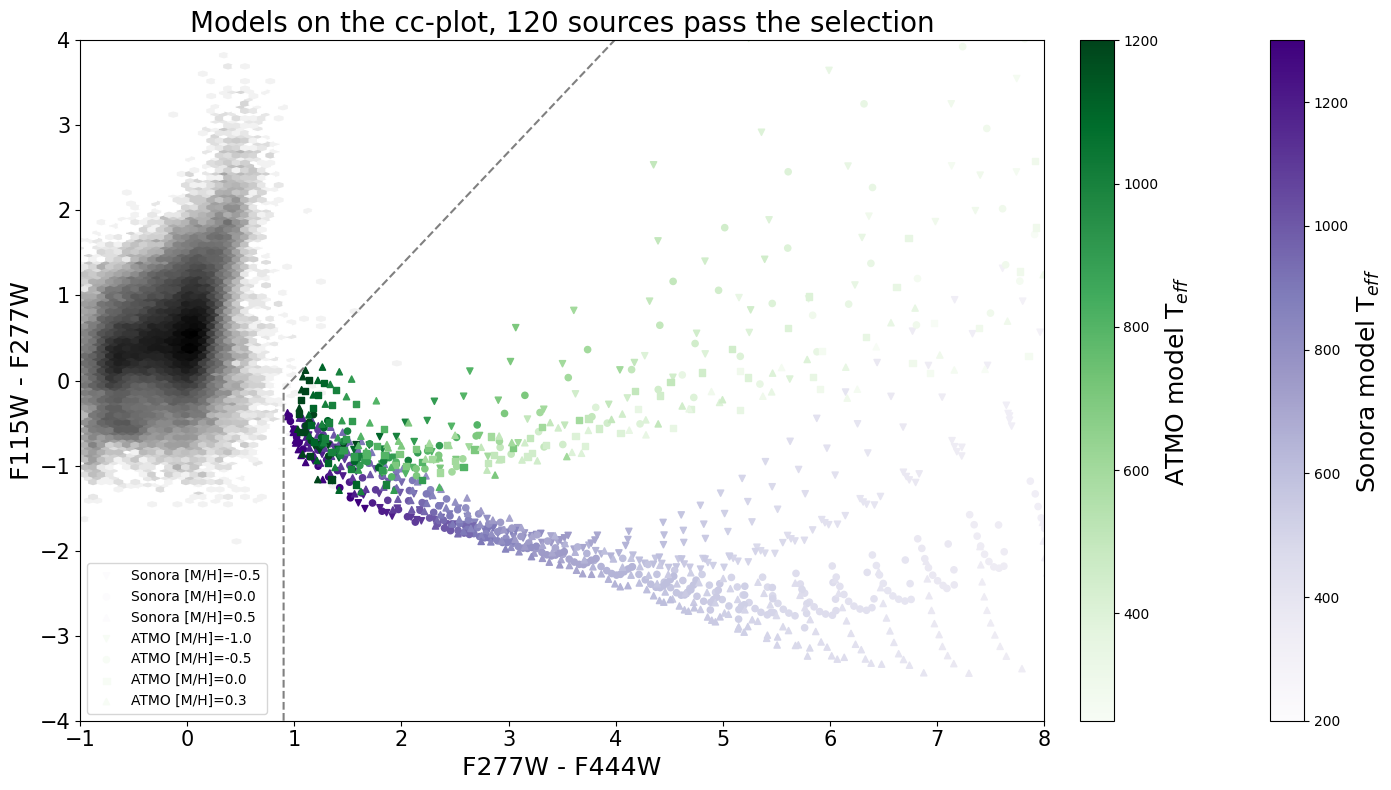

In [4]:
mask = (sources['MAG_AUTO_F444W']>10)&(sources['MAG_AUTO_F277W']>10)&(sources['MAG_AUTO_F150W']>10)&(sources['MAG_AUTO_F115W']>10)
m444 = sources[mask]['MAG_AUTO_F444W']
m277 = sources[mask]['MAG_AUTO_F277W']
m150 = sources[mask]['MAG_AUTO_F150W']
m115 = sources[mask]['MAG_AUTO_F115W']

# selection = (m277-m444>1.1)&(m115-m277<-0.8)
# selection = (m277-m444>1)
selection = (m277-m444>0.9)&(m115-m277+1<m277-m444)
pltlim = [8, -4]

fig, ax = plt.subplots(figsize=(15,8))

hb = ax.hexbin(
    m277-m444, m115-m277,
    gridsize=160, cmap='Greys', bins='log'
)
# ax.scatter(
#     (m277-m444)[selection], (m115-m277)[selection],
#     s=50, color='red', marker='*', label='Selected sources', alpha=0.5, zorder=10
# )
# ax.plot([1.1, 1.1, pltlim[0]], [pltlim[1], -0.8, -0.8], c='grey', ls='--')
# ax.plot([1, 1], [pltlim[1], pltlim[0]], c='grey', ls='--')
ax.plot([0.9, 0.9, 7], [pltlim[1], -0.1, pltlim[0]], c='grey', ls='--')

S_model = lambda z: Sonora_model[(Sonora_model['Z']==z)&(Sonora_model['Teff']<1310)]
A_model = lambda z: ATMO_model[(ATMO_model['[M/H]']==z)]
# (ATMO_model['log_g']==5)&
# (Sonora_model['log(g)']==5)&


for z, marker in zip([-0.5, 0.0, 0.5], ['v', 'o', '^']):
    sc = ax.scatter(
        S_model(z)['F277W']-S_model(z)['F444W'], S_model(z)['F115W']-S_model(z)['F277W'],
        label=f'Sonora [M/H]={z}', c = S_model(z)['Teff'], cmap='Purples', s=20, marker=marker
    )
cbar1 = fig.colorbar(sc, ax=ax, pad = 0.01)
cbar1.set_label('Sonora model T$_{eff}$', fontsize=18)

for z, marker in zip([-1.0, -0.5, 0.0, 0.3], ['v', 'o', 's', '^']):
    ac = ax.scatter(
        A_model(z)['F277W']-A_model(z)['F444W'], A_model(z)['F115W']-A_model(z)['F277W'],
        label=f'ATMO [M/H]={z}', c = A_model(z)['Teff'], cmap='Greens', s=20, marker=marker
    )
cbar2 = fig.colorbar(ac, ax=ax, pad = 0.03)
cbar2.set_label('ATMO model T$_{eff}$', fontsize=18)

ax.set_xlabel('F277W - F444W', fontsize=18)
ax.set_ylabel('F115W - F277W', fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=15)

ax.set_xlim(-1, pltlim[0])
ax.set_ylim(pltlim[1], 4)

ax.legend(loc = 'lower left', fontsize=10)

plt.title(f'Models on the cc-plot, {len(m444[selection])} sources pass the selection', fontsize=20)
plt.tight_layout()
plt.show()